In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv("data/earthquake_data_tsunami.csv")

In [3]:
#Visualizar os 5 primeiros dados
df.sample(5)

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
770,6.5,0,6,650,206,0.000,0.0,33.00,-4.0290,128.0200,2001,3,0
167,6.5,6,7,652,0,4.797,10.0,9.00,-16.0315,168.1430,2018,8,1
732,6.6,0,7,670,0,0.000,0.0,4.20,63.5144,-147.9120,2002,10,0
337,6.7,0,5,691,0,0.748,43.0,26.59,-29.9414,-177.6070,2014,6,0
18,7.2,7,5,876,144,2.494,40.0,236.00,-14.8628,-70.3081,2022,5,1


In [4]:
#
df.shape

(782, 13)

In [5]:
#Estatisticas das coluna numericas
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [7]:
print(df.isnull().sum()) #  Verificar valores nulos
print("Quantidade de valores duplicados: ",df.duplicated().sum()) #Soma dos valores duplicados

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64
Quantidade de valores duplicados:  0


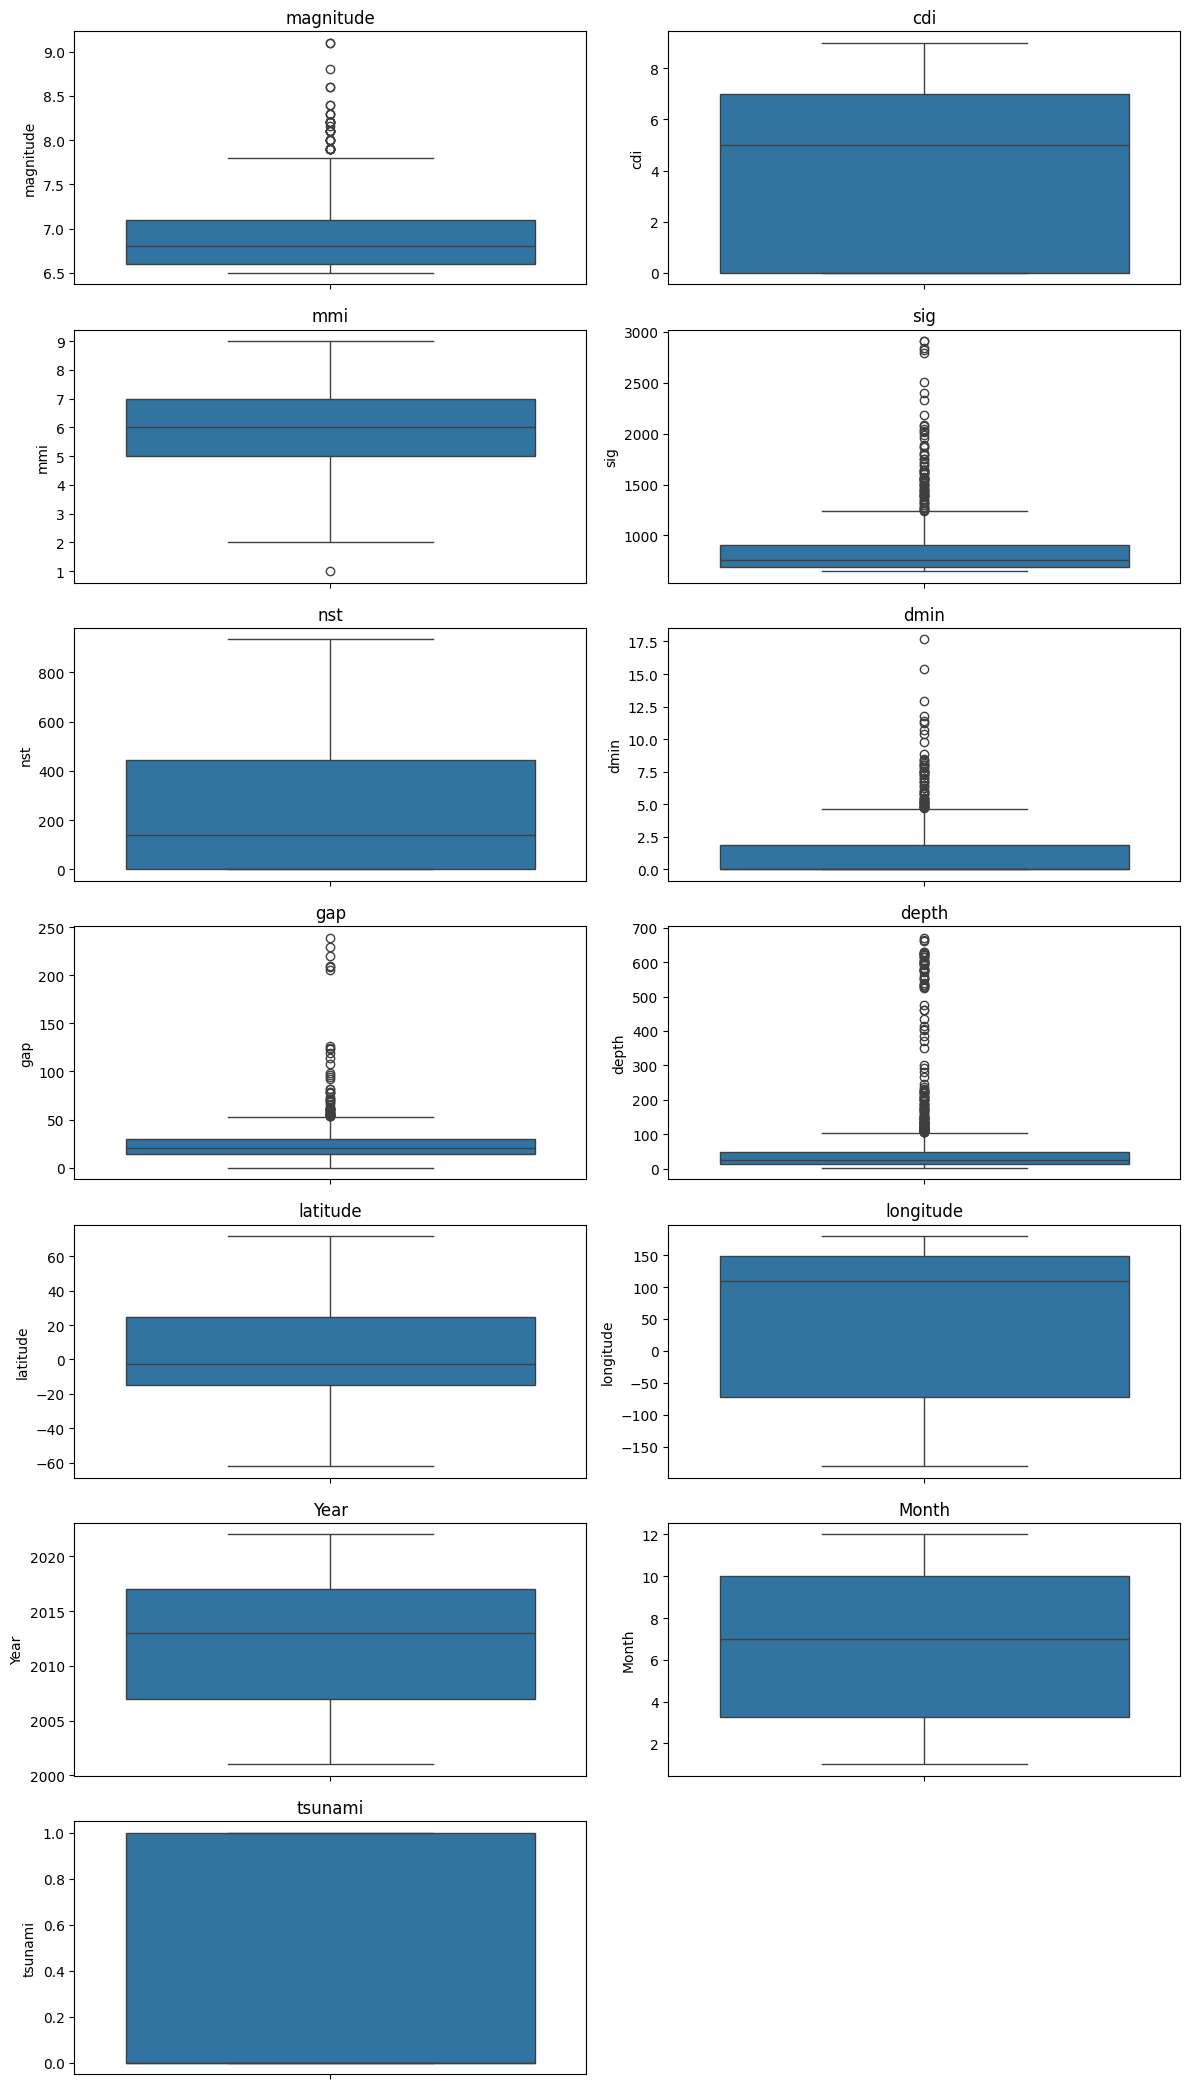

In [8]:
colunas = df.columns
n = len(colunas)
cols = 2               # número de colunas no grid
rows = math.ceil(n / cols)
plt.figure(figsize=(12,rows*3))
for i, col in enumerate(colunas, 1):
    plt.subplot(rows,cols, i)
    sns.boxplot(data=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: ylabel='depth'>

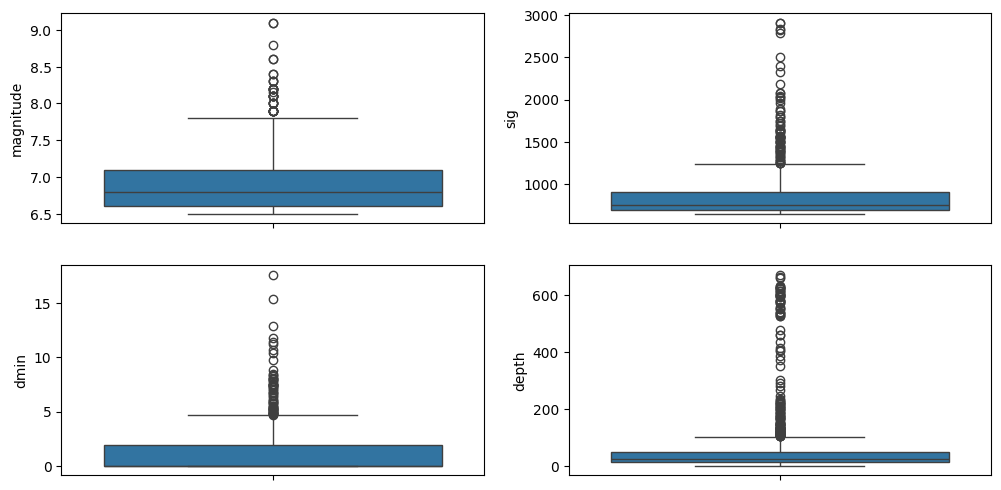

In [9]:
#Verificar Outliers(algumas colunas)
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.boxplot(data=df['magnitude'])

plt.subplot(2,2,2)
sns.boxplot(data=df['sig'])

plt.subplot(2,2,3)
sns.boxplot(data=df['dmin'])

plt.subplot(2,2,4)
sns.boxplot(data=df['depth'])

#Bastantes Outliers

<Axes: xlabel='depth', ylabel='Count'>

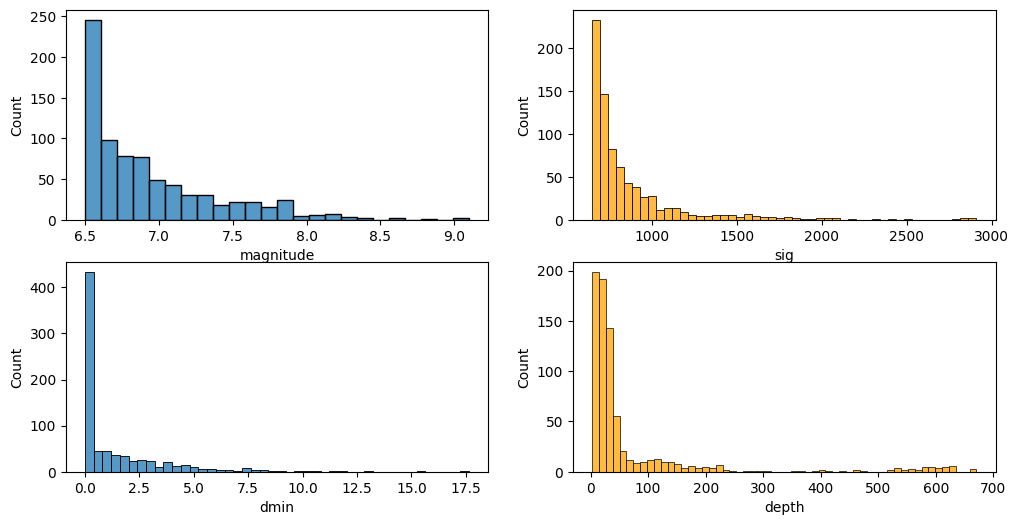

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.histplot(data=df['magnitude'])

plt.subplot(2,2,2)
sns.histplot(data=df['sig'],color='orange')

plt.subplot(2,2,3)
sns.histplot(data=df['dmin'])

plt.subplot(2,2,4)
sns.histplot(data=df['depth'],color='orange')

In [11]:
colunas_outliers = ['magnitude','sig','dmin','depth','gap']

for col in colunas_outliers:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR= q3-q1
    #print(col)
    # print(IQR)
    limite_inferior = q1 - 1.5*IQR
    limite_superior = q3 + 1.5*IQR
    #print(limite_superior, limite_inferior)
    outliers = df[(df[col]<=limite_inferior) | (df[col]>=limite_superior)]
    print(f"\nOutliers da coluna '{col}': {len(outliers)}")


Outliers da coluna 'magnitude': 37

Outliers da coluna 'sig': 73

Outliers da coluna 'dmin': 61

Outliers da coluna 'depth': 139

Outliers da coluna 'gap': 48


In [12]:
#Neste caso vamos manter os outliers, pederiamos muitos dados.
# Vamos utilizar o normaliador RobustScaller(para Logistic Regression e SVC) pq é menos sensivel a outliers.
# Para (Decision Tree / Random Forest) nao precisamos.

In [13]:
#Dividir o dataSet
X = df.drop(['tsunami','Year', 'Month'], axis=1) #Eliminar o Target e colunas irrelevantes
y = df['tsunami'] #Target

In [14]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=8)

In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(Xtrain)
X_test_scaled = scaler.transform(Xtest) #Normalizar

modelo = LogisticRegression()
modelo.fit(X_train_scaled,ytrain)
modelo.score(X_test_scaled,ytest)#Acuracia Acertos / Total

0.7857142857142857

In [16]:
#verificar os 5 primeiros de ytest com o previsto
previsao = modelo.predict(X_test_scaled)
for i in range(1,6):
    print("Real: ", ytest.iloc[i]) # ytest é uma serie por isso precisamos de iloc
    print("Previsao: ",previsao[i]) # previsao é um array acedemos diretamente pelo indice
    if (ytest.iloc[i] == previsao[i]):
        print("\tAcertou")
    else:
        print("\tErrou")

Real:  0
Previsao:  0
	Acertou
Real:  0
Previsao:  0
	Acertou
Real:  0
Previsao:  0
	Acertou
Real:  1
Previsao:  1
	Acertou
Real:  0
Previsao:  1
	Errou


In [17]:
#Testar outro modelo, fazer tuning(hiperparametros) e utilizar Pipelines
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV #tunning


pipe= Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression())
])

param_grid = [
    #LogisticRegression
    {
        'model': [LogisticRegression()],
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l2']
    },
    # SVC
    {
        'model': [SVC()],
        'model__C': [0.1, 1, 5, 10],
        'model__kernel': ['linear', 'rbf', 'poly'],
        'model__gamma': ['scale', 'auto']
    }
]

search = GridSearchCV(pipe,param_grid,cv=10,n_jobs=-1)
search.fit(Xtrain, ytrain)
modelo_otimo = search.best_estimator_
print("Melhor modelo e parâmetros:")
print(modelo_otimo)
print("Acurácia média (CV):", search.best_score_)

Melhor modelo e parâmetros:
Pipeline(steps=[('scaler', RobustScaler()), ('model', SVC(C=5))])
Acurácia média (CV): 0.840999415546464


In [18]:
print("Acurácia: ",modelo_otimo.score(Xtest,ytest))

Acurácia:  0.8112244897959183


In [19]:
from sklearn.metrics import classification_report #Verificar metricas de classificação

y_pred = modelo_otimo.predict(Xtest)
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84       132
           1       0.64      0.95      0.77        64

    accuracy                           0.81       196
   macro avg       0.81      0.85      0.80       196
weighted avg       0.86      0.81      0.82       196



In [20]:
#Precision -> Quantos dos casos que o modelo previu como positivos (ou 1) eram realmente positivos.
#Recall (sensibilidade) -> Quantos dos casos reais positivos o modelo conseguiu identificar.
#F1-score -> Média harmónica entre precision e recall, equilibrando os dois.
#Support -> Número de exemplos reais de cada classe no conjunto de teste.
#
# Como prever tsunamis é crítico (errado = risco), o alto recall para tsunamis é bom, mesmo que tenha falsos alarmes.

[[98 34]
 [ 3 61]]


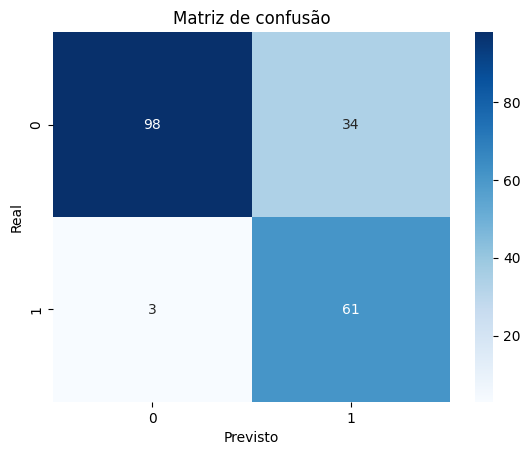

In [21]:
from sklearn.metrics import confusion_matrix #Avalia a acuracia do modelo

y_pred = modelo_otimo.predict(Xtest)

cm = confusion_matrix(ytest,y_pred)
print(cm)

sns.heatmap(cm,annot=True,cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title("Matriz de confusão")
plt.show()

     feature  importance
4        nst    0.220918
3        sig    0.021429
5       dmin    0.021429
7      depth    0.015816
2        mmi    0.009694
8   latitude    0.005612
6        gap    0.003571
0  magnitude   -0.004592
9  longitude   -0.010204
1        cdi   -0.029592


C:\Users\Francisco Guedes\AppData\Local\Temp\ipykernel_9048\2010440231.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


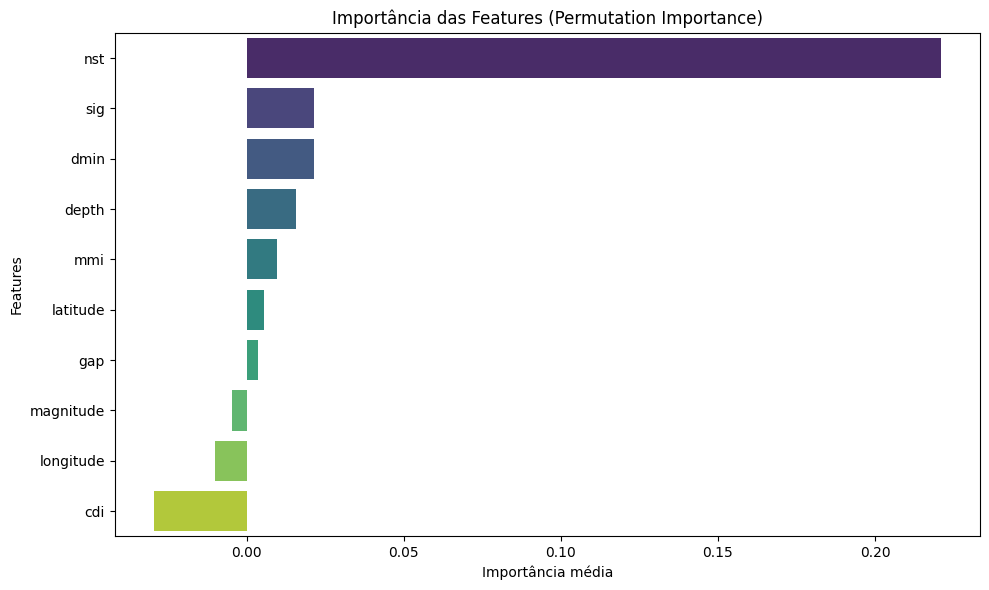

In [22]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo_otimo, Xtest, ytest, n_repeats=10, random_state=8)

importance_df = pd.DataFrame({'feature': Xtrain.columns, 'importance': result.importances_mean})
importance_df.sort_values(by='importance', ascending=False, inplace=True)
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title("Importância das Features (Permutation Importance)")
plt.xlabel("Importância média")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [23]:
import joblib
joblib.dump(modelo_otimo, "models/modelo_tsunami_normalizado.pkl")

['models/modelo_tsunami_normalizado.pkl']